# AI5707 – Pattern Recognition and Machine Learning
## Assignment 5: Maximum Likelihood Parameter Estimation

This notebook implements both parts of the assignment:

1. Generate 10,000 samples for each of three Gaussian classes; compare isotropic, diagonal, and full covariance assumptions under shared and class-specific covariance models.
2. Fit Gaussian models using maximum-likelihood estimates on the supplied `train.txt` file and evaluate on the held-out `dev.txt` file. The original split is preserved to avoid test-data leakage. The loader also recognizes `dev(2).txt`.

The notebook reports classification accuracy, per-class precision/recall/F1, confusion matrices, decision boundaries with held-out samples, and multiclass ROC/AUC results. Run all cells from top to bottom. Keep the dataset files in the same folder as this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, roc_curve, auc, roc_auc_score
from matplotlib.colors import ListedColormap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True


## 1. Maximum-likelihood estimation

For class \(i\), the MLE estimates are
\[
\hat{\mu}_i=\frac{1}{n_i}\sum_{k=1}^{n_i}x_k,\qquad
\hat{\Sigma}_i=\frac{1}{n_i}\sum_{k=1}^{n_i}(x_k-\hat{\mu}_i)(x_k-\hat{\mu}_i)^T.
\]
The covariance denominator is \(n_i\), as required by maximum likelihood. The Gaussian classifier uses log-likelihood plus empirical class log-prior. A small diagonal regularizer is used for numerical stability.


In [2]:
def fit_gaussian_classifier(X, y, covariance_type="full", shared_covariance=False, reg=1e-6):
    """Fit Gaussian class-conditional models using maximum likelihood (denominator n)."""
    X, y = np.asarray(X, dtype=float), np.asarray(y)
    if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
        raise ValueError("X must be 2-D and y must be 1-D with the same number of rows")
    if len(X) == 0 or not np.isfinite(X).all():
        raise ValueError("X must be non-empty and contain only finite values")
    if covariance_type not in {"isotropic", "diagonal", "full"}:
        raise ValueError("covariance_type must be isotropic, diagonal, or full")
    if reg <= 0:
        raise ValueError("reg must be positive")

    classes = np.unique(y)
    n, d = X.shape
    means, covs, priors = {}, {}, {}

    for cls in classes:
        Xc = X[y == cls]
        if len(Xc) == 0:
            raise ValueError(f"No training samples for class {cls}")
        mu = Xc.mean(axis=0)
        centered = Xc - mu
        mle_cov = centered.T @ centered / len(Xc)
        if covariance_type == "isotropic":
            cov = np.eye(d) * (np.trace(mle_cov) / d)
        elif covariance_type == "diagonal":
            cov = np.diag(np.diag(mle_cov))
        else:
            cov = mle_cov
        means[cls], covs[cls], priors[cls] = mu, cov, len(Xc) / n

    if shared_covariance:
        # MLE pooled within-class covariance, centred at each class's own MLE mean.
        pooled = np.zeros((d, d))
        for cls in classes:
            centered = X[y == cls] - means[cls]
            pooled += centered.T @ centered
        pooled /= n
        if covariance_type == "isotropic":
            pooled = np.eye(d) * (np.trace(pooled) / d)
        elif covariance_type == "diagonal":
            pooled = np.diag(np.diag(pooled))
        covs = {cls: pooled.copy() for cls in classes}

    return {"classes": classes, "means": means, "covariances": covs,
            "priors": priors, "reg": float(reg),
            "covariance_type": covariance_type,
            "shared_covariance": bool(shared_covariance)}


def log_gaussian_pdf(X, mean, cov, reg=1e-6):
    """Stable Gaussian log-density evaluated row-wise for X."""
    X = np.asarray(X, dtype=float)
    d = X.shape[1]
    cov_reg = np.asarray(cov, dtype=float) + reg * np.eye(d)
    sign, logdet = np.linalg.slogdet(cov_reg)
    if sign <= 0 or not np.isfinite(logdet):
        cov_reg = cov_reg + max(1e-8, 100 * reg) * np.eye(d)
        sign, logdet = np.linalg.slogdet(cov_reg)
    if sign <= 0 or not np.isfinite(logdet):
        raise np.linalg.LinAlgError("Covariance matrix is not positive definite after regularization")
    diff = X - mean
    solved = np.linalg.solve(cov_reg, diff.T).T
    quad = np.sum(diff * solved, axis=1)
    return -0.5 * (d * np.log(2 * np.pi) + logdet + quad)


def gaussian_class_scores(model, X):
    """Log joint scores log p(x|class) + log prior, one column per class."""
    return np.column_stack([
        log_gaussian_pdf(X, model["means"][cls], model["covariances"][cls], model["reg"])
        + np.log(model["priors"][cls])
        for cls in model["classes"]
    ])


def predict_gaussian_classifier(model, X):
    scores = gaussian_class_scores(model, X)
    return model["classes"][np.argmax(scores, axis=1)]


def evaluate_model(model, X_test, y_test, title):
    pred = predict_gaussian_classifier(model, X_test)
    labels = model["classes"]
    cm = confusion_matrix(y_test, pred, labels=labels)
    print(f"{title} | accuracy = {accuracy_score(y_test, pred):.4f}")
    display(pd.DataFrame(cm, index=[f"True {c}" for c in labels],
                         columns=[f"Pred {c}" for c in labels]))
    print(classification_report(y_test, pred, labels=labels, zero_division=0, digits=4))
    return pred, cm


def plot_decision_boundary(model, X_test, y_test, title, max_points=2500):
    X_test, y_test = np.asarray(X_test), np.asarray(y_test)
    if X_test.ndim != 2 or X_test.shape[1] != 2:
        raise ValueError("Decision-boundary plotting requires exactly two features")
    pad = 1.0
    xx, yy = np.meshgrid(
        np.linspace(X_test[:, 0].min() - pad, X_test[:, 0].max() + pad, 240),
        np.linspace(X_test[:, 1].min() - pad, X_test[:, 1].max() + pad, 240))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = predict_gaussian_classifier(model, grid).reshape(xx.shape)
    classes = model["classes"]
    colors = ["#d9e8ff", "#ffe0d6", "#d9f3df", "#eee0ff", "#fff0b3"]
    cmap = ListedColormap(colors[:len(classes)])
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=.55, cmap=cmap)
    ids = np.arange(len(X_test))
    if len(ids) > max_points:
        ids = np.random.default_rng(0).choice(ids, max_points, replace=False)
    for cls in classes:
        mask = y_test[ids] == cls
        plt.scatter(X_test[ids][mask, 0], X_test[ids][mask, 1],
                    s=18, alpha=.8, edgecolors="black", linewidths=.2, label=f"Class {cls}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title + (f" (showing {len(ids)} test points)" if len(X_test) > max_points else ""))
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2. Synthetic data experiments

Each class contains 10,000 samples. The notebook evaluates all three covariance structures for both (i) shared covariance across classes and (ii) class-specific covariance matrices.



Shared covariance
Train: 24000 | Test: 6000
Isotropic covariance | accuracy = 0.9940


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1982,18
True 3,0,18,1982


              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000      2000
           2     0.9910    0.9910    0.9910      2000
           3     0.9910    0.9910    0.9910      2000

    accuracy                         0.9940      6000
   macro avg     0.9940    0.9940    0.9940      6000
weighted avg     0.9940    0.9940    0.9940      6000



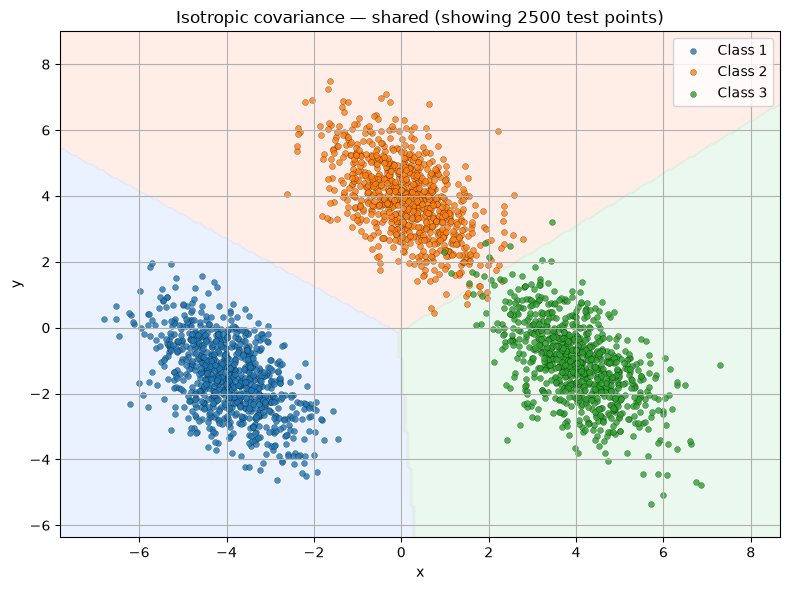

Diagonal covariance | accuracy = 0.9945


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1988,12
True 3,0,21,1979


              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000      2000
           2     0.9895    0.9940    0.9918      2000
           3     0.9940    0.9895    0.9917      2000

    accuracy                         0.9945      6000
   macro avg     0.9945    0.9945    0.9945      6000
weighted avg     0.9945    0.9945    0.9945      6000



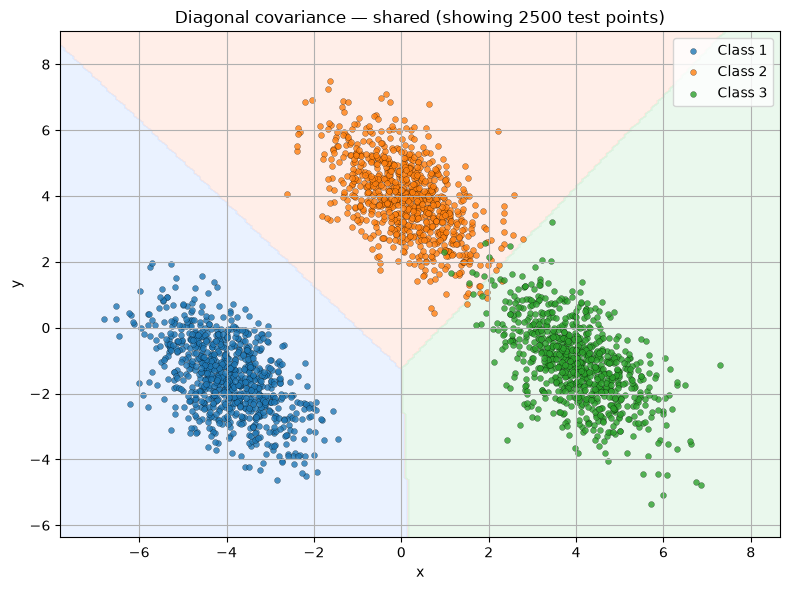

Full covariance | accuracy = 0.9943


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1987,13
True 3,0,21,1979


              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000      2000
           2     0.9895    0.9935    0.9915      2000
           3     0.9935    0.9895    0.9915      2000

    accuracy                         0.9943      6000
   macro avg     0.9943    0.9943    0.9943      6000
weighted avg     0.9943    0.9943    0.9943      6000



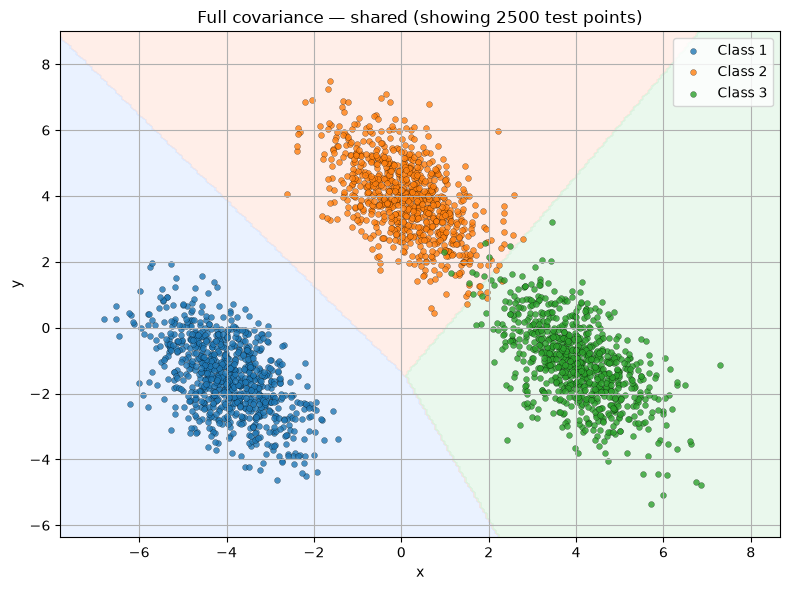


Different covariance per class
Train: 24000 | Test: 6000
Isotropic covariance | accuracy = 0.9962


,Pred 1,Pred 2,Pred 3
True 1,1999,1,0
True 2,0,1978,22
True 3,0,0,2000


              precision    recall  f1-score   support

           1     1.0000    0.9995    0.9997      2000
           2     0.9995    0.9890    0.9942      2000
           3     0.9891    1.0000    0.9945      2000

    accuracy                         0.9962      6000
   macro avg     0.9962    0.9962    0.9962      6000
weighted avg     0.9962    0.9962    0.9962      6000



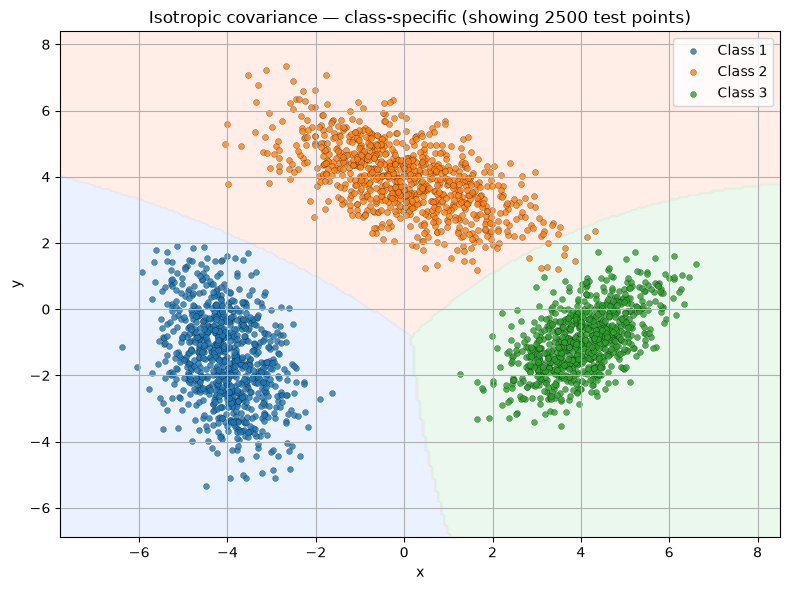

Diagonal covariance | accuracy = 0.9960


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1976,24
True 3,0,0,2000


              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000      2000
           2     1.0000    0.9880    0.9940      2000
           3     0.9881    1.0000    0.9940      2000

    accuracy                         0.9960      6000
   macro avg     0.9960    0.9960    0.9960      6000
weighted avg     0.9960    0.9960    0.9960      6000



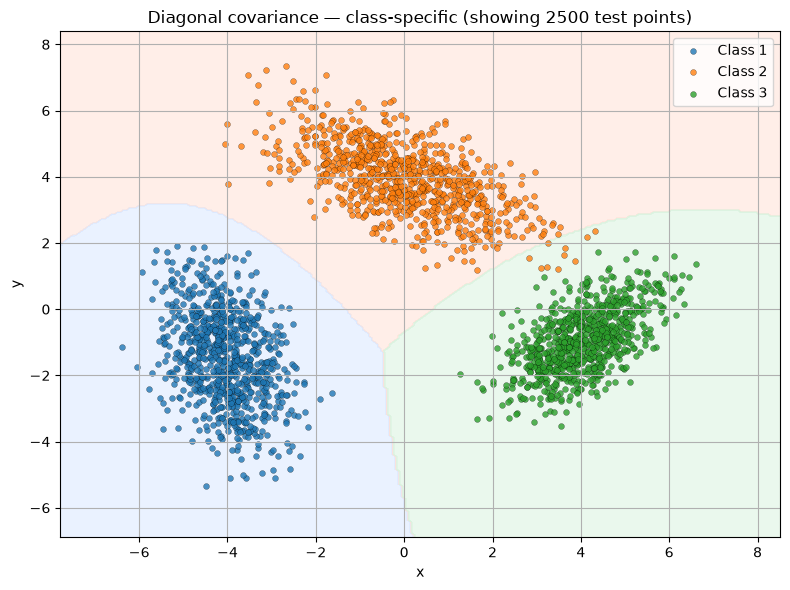

Full covariance | accuracy = 0.9993


,Pred 1,Pred 2,Pred 3
True 1,2000,0,0
True 2,0,1998,2
True 3,0,2,1998


              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000      2000
           2     0.9990    0.9990    0.9990      2000
           3     0.9990    0.9990    0.9990      2000

    accuracy                         0.9993      6000
   macro avg     0.9993    0.9993    0.9993      6000
weighted avg     0.9993    0.9993    0.9993      6000



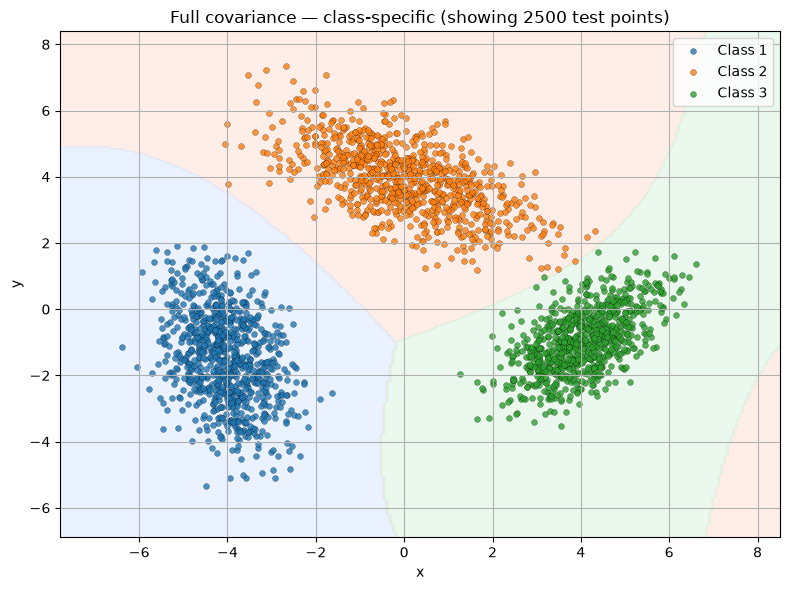

,Covariance setting,Covariance model,Test accuracy
0,Shared,isotropic,0.994000
1,Shared,diagonal,0.994500
2,Shared,full,0.994333
3,Class-specific,isotropic,0.996167
4,Class-specific,diagonal,0.996000
5,Class-specific,full,0.999333


In [3]:
means_synthetic = {
    1: np.array([-4.0, -1.5]),
    2: np.array([0.0, 4.0]),
    3: np.array([4.0, -1.0])
}

def rotated_cov(scale=1.0, angle=0.0):
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]])
    D = np.diag([0.45*scale, 1.8*scale])
    return R @ D @ R.T

shared_cov = rotated_cov(1.0, 0.55)
class_covs = {
    1: rotated_cov(1.0, 0.2),
    2: rotated_cov(1.4, 1.0),
    3: rotated_cov(0.8, -0.7)
}

def generate_data(n_per_class=10000, shared=True, seed=42):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for cls, mu in means_synthetic.items():
        cov = shared_cov if shared else class_covs[cls]
        Xs.append(rng.multivariate_normal(mu, cov, n_per_class))
        ys.append(np.full(n_per_class, cls))
    return np.vstack(Xs), np.concatenate(ys)

synthetic_results = []
for shared in [True, False]:
    X, y = generate_data(shared=shared, seed=RANDOM_STATE + int(not shared))
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=.20, random_state=RANDOM_STATE, stratify=y)
    print("\n" + "="*75)
    print("Shared covariance" if shared else "Different covariance per class")
    print("Train:", len(Xtr), "| Test:", len(Xte))
    for cov_type in ["isotropic", "diagonal", "full"]:
        model = fit_gaussian_classifier(Xtr, ytr, cov_type, shared_covariance=shared)
        pred, _ = evaluate_model(model, Xte, yte, f"{cov_type.title()} covariance")
        synthetic_results.append({
            "Covariance setting": "Shared" if shared else "Class-specific",
            "Covariance model": cov_type,
            "Test accuracy": accuracy_score(yte, pred)
        })
        plot_decision_boundary(model, Xte, yte,
            f"{cov_type.title()} covariance — {'shared' if shared else 'class-specific'}")
display(pd.DataFrame(synthetic_results))


## 3. Provided 2-D dataset

The supplied files are treated as a pre-defined training/held-out split: `train.txt` is used only for parameter estimation, and `dev.txt` (or `dev(2).txt`) is used only for evaluation. This avoids leakage from the evaluation set into model fitting. The assignment asks for approximately an 80/20 split; the provided files may not have exactly that ratio, so their actual sizes are reported below.

Rows must contain numeric `x, y, class_label` values, separated by commas or whitespace. Exact duplicate rows are retained because repeated observations may be meaningful. Invalid rows and non-integer class labels are reported as errors rather than silently dropped or truncated.

In [4]:
def locate_file(names):
    for name in names:
        path = Path(name)
        if path.is_file():
            return path
    return None

train_path = locate_file(["train.txt"])
dev_path = locate_file(["dev.txt"])


def load_dataset(path):
    # Accept comma-separated or whitespace-separated three-column files.
    df = pd.read_csv(path, header=None, comment="#", sep=r"[,\s]+", engine="python",
                     skipinitialspace=True)
    if df.shape[1] != 3:
        raise ValueError(f"{path} must contain exactly three columns: x, y, class_label; found {df.shape[1]}")
    df.columns = ["x", "y", "label"]
    numeric = df.apply(pd.to_numeric, errors="coerce")
    if numeric.isna().any().any():
        bad_rows = numeric.index[numeric.isna().any(axis=1)].tolist()[:10]
        raise ValueError(f"{path} contains missing/non-numeric values (example row indices: {bad_rows})")
    if not np.isfinite(numeric[["x", "y"]].to_numpy(dtype=float)).all():
        raise ValueError(f"{path} contains non-finite feature values")
    labels = numeric["label"].to_numpy(dtype=float)
    if not np.equal(labels, np.floor(labels)).all():
        raise ValueError(f"{path} contains non-integer class labels")
    numeric["label"] = labels.astype(int)
    if numeric["label"].nunique() < 2:
        raise ValueError(f"{path} must contain at least two classes")
    return numeric

if train_path is None or dev_path is None:
    print("Dataset files not found. Put train.txt and dev.txt (or dev(2).txt) in the same folder as this notebook.")
    print("The synthetic-data section still runs; real-data evaluation and ROC/AUC are skipped until both files are present.")
else:
    train_df = load_dataset(train_path)
    dev_df = load_dataset(dev_path)
    train_classes = set(train_df["label"].unique())
    dev_classes = set(dev_df["label"].unique())
    if train_classes != dev_classes:
        raise ValueError(f"Training classes {sorted(train_classes)} differ from held-out classes {sorted(dev_classes)}")
    print(f"Training file: {train_path} — {len(train_df)} rows")
    print(f"Held-out file: {dev_path} — {len(dev_df)} rows")
    total = len(train_df) + len(dev_df)
    print(f"Combined total: {total}; train proportion: {len(train_df)/total:.1%}; held-out proportion: {len(dev_df)/total:.1%}")
    print("Training class counts:")
    display(train_df["label"].value_counts().sort_index().rename("count").to_frame())
    print("Held-out class counts:")
    display(dev_df["label"].value_counts().sort_index().rename("count").to_frame())
    display(train_df.head())

Training file: train.txt — 1050 rows
Held-out file: dev.txt — 300 rows
Combined total: 1350; train proportion: 77.8%; held-out proportion: 22.2%
Training class counts:


,count
label,
1,350
2,350
3,350


Held-out class counts:


,count
label,
1,100
2,100
3,100


,x,y,label
0,500.00,1500.00,1
1,294.34,816.89,1
2,371.01,1207.70,1
3,390.96,2069.80,1
4,500.00,1500.00,1


## 4. Fit and evaluate on the provided split

For each covariance model, parameters are estimated from `train.txt` only. Predictions and all reported metrics are computed on `dev.txt` only. No rows are merged, deduplicated, or reassigned between these files.

Training samples: 1050 | Held-out samples: 300
Held-out data — Isotropic covariance | accuracy = 0.8233


,Pred 1,Pred 2,Pred 3
True 1,74,4,22
True 2,2,87,11
True 3,9,5,86


              precision    recall  f1-score   support

           1     0.8706    0.7400    0.8000       100
           2     0.9062    0.8700    0.8878       100
           3     0.7227    0.8600    0.7854       100

    accuracy                         0.8233       300
   macro avg     0.8332    0.8233    0.8244       300
weighted avg     0.8332    0.8233    0.8244       300



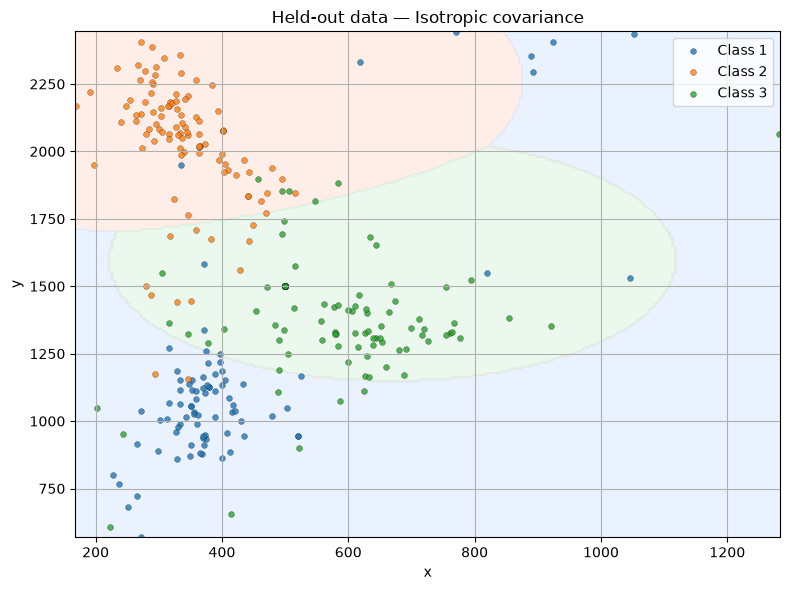

Held-out data — Diagonal covariance | accuracy = 0.8467


,Pred 1,Pred 2,Pred 3
True 1,78,2,20
True 2,6,89,5
True 3,12,1,87


              precision    recall  f1-score   support

           1     0.8125    0.7800    0.7959       100
           2     0.9674    0.8900    0.9271       100
           3     0.7768    0.8700    0.8208       100

    accuracy                         0.8467       300
   macro avg     0.8522    0.8467    0.8479       300
weighted avg     0.8522    0.8467    0.8479       300



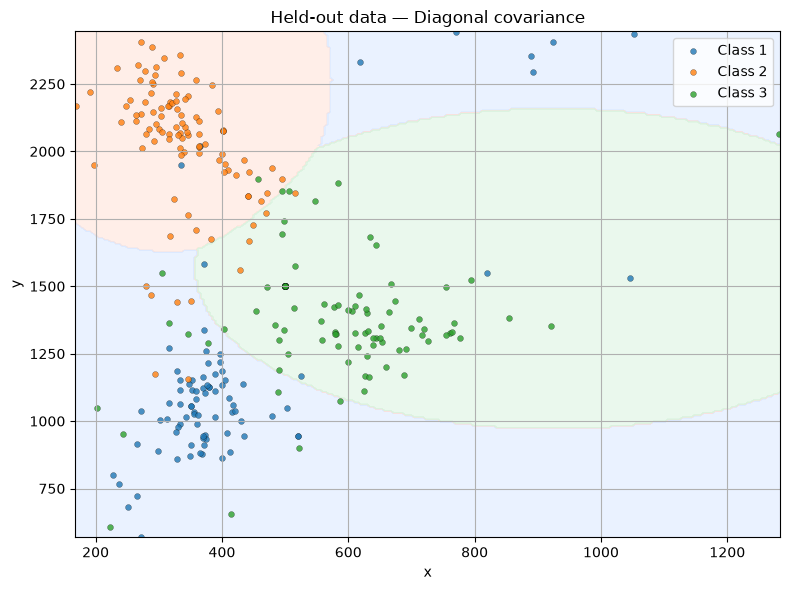

Held-out data — Full covariance | accuracy = 0.8433


,Pred 1,Pred 2,Pred 3
True 1,78,2,20
True 2,6,91,3
True 3,13,3,84


              precision    recall  f1-score   support

           1     0.8041    0.7800    0.7919       100
           2     0.9479    0.9100    0.9286       100
           3     0.7850    0.8400    0.8116       100

    accuracy                         0.8433       300
   macro avg     0.8457    0.8433    0.8440       300
weighted avg     0.8457    0.8433    0.8440       300



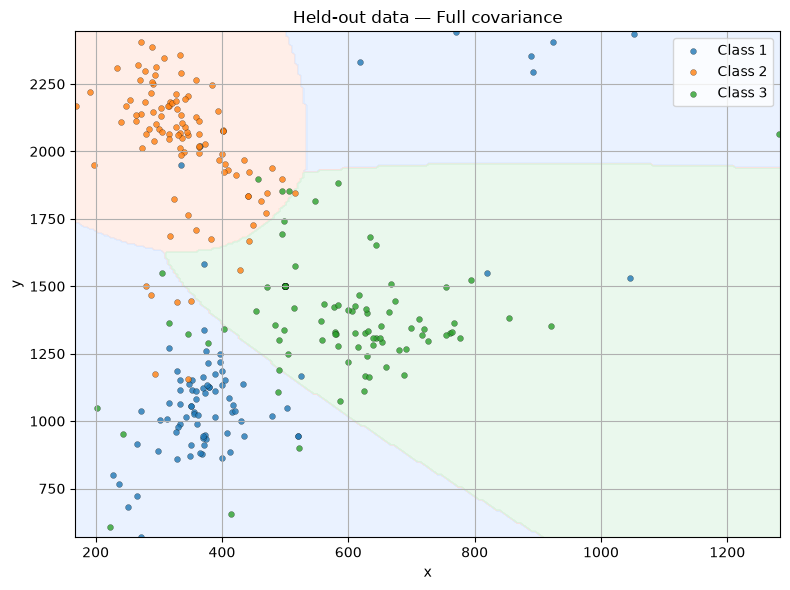

,Covariance model,Accuracy,Macro precision,Macro recall,Macro F1
1,Diagonal,0.8467,0.8522,0.8467,0.8479
2,Full,0.8433,0.8457,0.8433,0.8440
0,Isotropic,0.8233,0.8332,0.8233,0.8244


In [5]:
if train_path is not None and dev_path is not None:
    Xtr_real = train_df[["x", "y"]].to_numpy(dtype=float)
    ytr_real = train_df["label"].to_numpy(dtype=int)
    Xte_real = dev_df[["x", "y"]].to_numpy(dtype=float)
    yte_real = dev_df["label"].to_numpy(dtype=int)
    print(f"Training samples: {len(Xtr_real)} | Held-out samples: {len(Xte_real)}")

    real_results = []
    real_models = {}
    for cov_type in ["isotropic", "diagonal", "full"]:
        model = fit_gaussian_classifier(Xtr_real, ytr_real, covariance_type=cov_type,
                                        shared_covariance=False)
        real_models[cov_type] = model
        pred, cm = evaluate_model(model, Xte_real, yte_real,
                                  f"Held-out data — {cov_type.title()} covariance")
        report = classification_report(yte_real, pred, labels=model["classes"],
                                       output_dict=True, zero_division=0)
        real_results.append({
            "Covariance model": cov_type.title(),
            "Accuracy": accuracy_score(yte_real, pred),
            "Macro precision": report["macro avg"]["precision"],
            "Macro recall": report["macro avg"]["recall"],
            "Macro F1": report["macro avg"]["f1-score"]
        })
        plot_decision_boundary(model, Xte_real, yte_real,
                               f"Held-out data — {cov_type.title()} covariance")
    real_results_df = pd.DataFrame(real_results).sort_values("Accuracy", ascending=False)
    display(real_results_df.style.format({c: "{:.4f}" for c in real_results_df.columns if c != "Covariance model"}))
else:
    real_models = {}
    print("Skipped: provide both train.txt and dev.txt to run the real-data evaluation.")

## 5. ROC curves and AUC

For multiclass classification, one-vs-rest ROC curves are computed from normalized posterior probabilities, with a micro-average curve. Posterior probabilities are obtained by applying softmax to the class log-joint scores. ROC/AUC is evaluated on the same held-out `dev.txt` samples used for the confusion matrices.


Isotropic covariance — held-out dev data


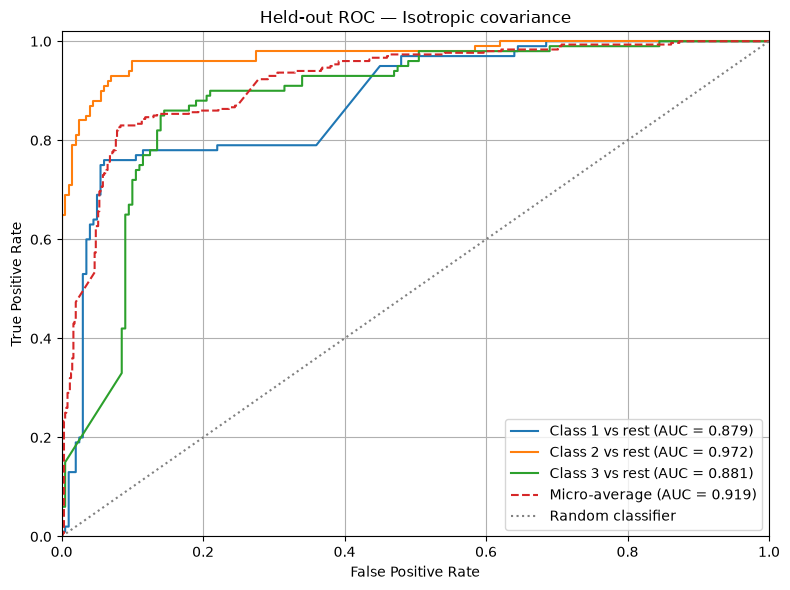

Per-class AUC: {'1': 0.8785, '2': 0.9721, '3': 0.8808}
Macro-average AUC: 0.9105
Micro-average AUC: 0.9188

Diagonal covariance — held-out dev data


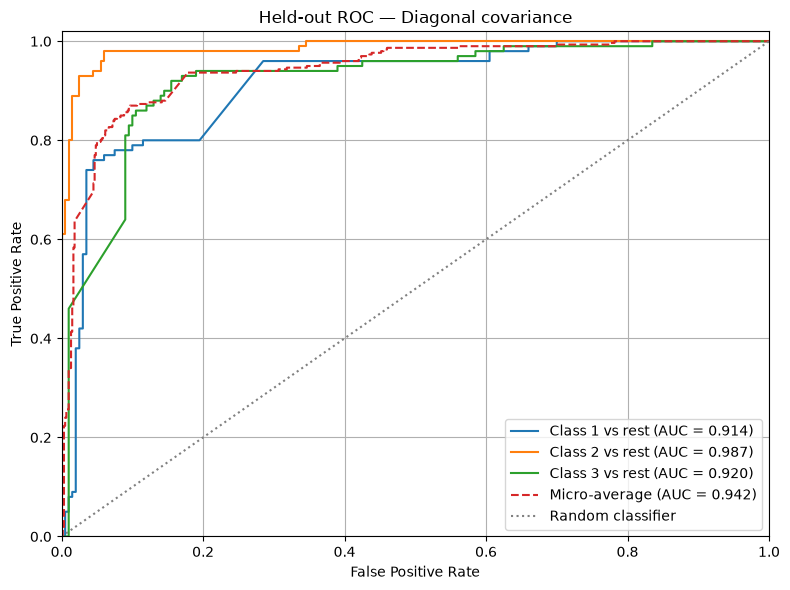

Per-class AUC: {'1': 0.9135, '2': 0.9866, '3': 0.9199}
Macro-average AUC: 0.9400
Micro-average AUC: 0.9422

Full covariance — held-out dev data


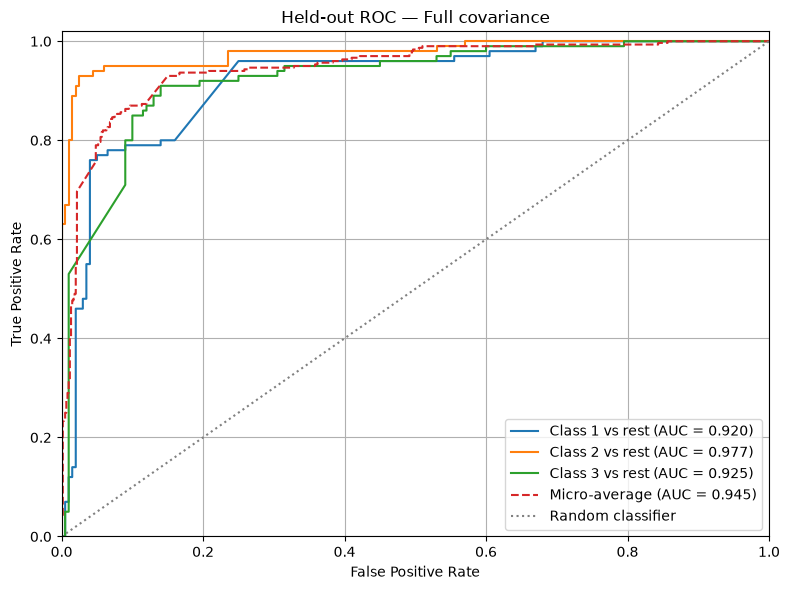

Per-class AUC: {'1': 0.9197, '2': 0.9772, '3': 0.9252}
Macro-average AUC: 0.9407
Micro-average AUC: 0.9450


,Covariance model,Macro AUC,Micro AUC
2,Full,0.9407,0.9450
1,Diagonal,0.9400,0.9422
0,Isotropic,0.9105,0.9188


In [6]:
from sklearn.preprocessing import label_binarize
from scipy.special import softmax


def gaussian_class_probabilities(model, X):
    """Return normalized posterior probabilities, one column per model class."""
    return softmax(gaussian_class_scores(model, X), axis=1)


def plot_multiclass_roc(model, X_test, y_test, title="Multiclass ROC"):
    classes = model["classes"]
    probabilities = gaussian_class_probabilities(model, X_test)
    y_bin = label_binarize(y_test, classes=classes)
    if len(classes) == 2:
        y_bin = np.column_stack([1 - y_bin[:, 0], y_bin[:, 0]])

    plt.figure(figsize=(8, 6))
    per_class_auc = {}
    for i, cls in enumerate(classes):
        # ROC is undefined if the held-out data has no positive or no negative examples.
        if np.unique(y_bin[:, i]).size < 2:
            print(f"Warning: ROC for class {cls} is undefined on this held-out split.")
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], probabilities[:, i])
        class_auc = auc(fpr, tpr)
        per_class_auc[str(cls)] = float(class_auc)
        plt.plot(fpr, tpr, label=f"Class {cls} vs rest (AUC = {class_auc:.3f})")

    if np.unique(y_bin.ravel()).size == 2:
        fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probabilities.ravel())
        micro_auc = float(auc(fpr_micro, tpr_micro))
        plt.plot(fpr_micro, tpr_micro, linestyle="--",
                 label=f"Micro-average (AUC = {micro_auc:.3f})")
    else:
        micro_auc = float("nan")
    plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    macro_auc = float(np.mean(list(per_class_auc.values()))) if per_class_auc else float("nan")
    print("Per-class AUC:", {k: round(v, 4) for k, v in per_class_auc.items()})
    print(f"Macro-average AUC: {macro_auc:.4f}")
    print(f"Micro-average AUC: {micro_auc:.4f}")
    return {"per_class_auc": per_class_auc, "macro_auc": macro_auc, "micro_auc": micro_auc}


if train_path is not None and dev_path is not None:
    roc_results = []
    for cov_type in ["isotropic", "diagonal", "full"]:
        model = real_models[cov_type]
        print(f"\n{cov_type.title()} covariance — held-out dev data")
        result = plot_multiclass_roc(
            model, Xte_real, yte_real,
            title=f"Held-out ROC — {cov_type.title()} covariance")
        roc_results.append({"Covariance model": cov_type.title(),
                            "Macro AUC": result["macro_auc"],
                            "Micro AUC": result["micro_auc"]})
    roc_results_df = pd.DataFrame(roc_results).sort_values("Macro AUC", ascending=False)
    display(roc_results_df.style.format({"Macro AUC": "{:.4f}", "Micro AUC": "{:.4f}"}))
else:
    print("Skipped ROC/AUC: provide both train.txt and dev.txt.")

## 6. Observations and conclusions

Use the actual tables and plots generated during execution to write the final observations. Discuss:

1. **Covariance assumptions:** isotropic covariance assumes equal variance in every direction; diagonal covariance allows feature-specific variances but ignores correlations; full covariance models correlations as well.
2. **Shared versus class-specific covariance:** shared covariance uses one pooled within-class covariance estimate, while class-specific covariance allows each class to have a different shape.
3. **Synthetic data:** compare the six recorded test accuracies and explain whether the assumed covariance structure matches the data-generating process.
4. **Provided data:** identify the best model using held-out accuracy, and use the confusion matrix and class-wise recall to identify which classes are most often confused.
5. **ROC/AUC:** compare per-class, macro-average, and micro-average AUC using normalized posterior probabilities. AUC measures ranking performance across thresholds, whereas accuracy measures predictions at the selected decision rule.
6. **Evaluation protocol:** the provided training and held-out files are kept separate. Their actual sizes and proportions are printed, and no deduplication is applied silently.

Do not copy old saved metric values after changing the data split or ROC scoring. Report the values generated by a fresh run with your actual dataset files.